# 01 — Exploratory Data Analysis

Catalog-level overview of the **South Asia earthquake catalog** built by
`src.fetch_usgs` (USGS FDSNWS, 1973–present, M ≥ 3.5, lat 23–38°, lon 60–78°).

This notebook answers four questions before any feature engineering:

1. **Scope** — how big is the catalog, what fields does it have?
2. **Magnitude completeness** — above what magnitude is the catalog reliable?
3. **Geography & depth** — where do these earthquakes happen, and how deep?
4. **Time** — how does the catalog evolve, and is detection improving?

It also flags **data-quality** issues (missing fields, encoding artefacts) that
the report should disclose.

See [PROJECT_PROPOSAL.md](../PROJECT_PROPOSAL.md) section 7 (Phase B).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid")
print("OK")

OK


## 1. Scope — load the catalog and inspect its shape

In [2]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "catalog.parquet")
print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Period:  {df['time'].min().date()}  →  {df['time'].max().date()}")
print(f"Region:  lat {df['latitude'].min():.2f}–{df['latitude'].max():.2f}, "
      f"lon {df['longitude'].min():.2f}–{df['longitude'].max():.2f}")
print(f"Mag:     {df['mag'].min():.1f}  →  {df['mag'].max():.1f}")
df.head()

Rows:    12,866
Columns: 15
Period:  1973-01-02  →  2026-05-06
Region:  lat 23.02–38.00, lon 60.00–78.00
Mag:     3.5  →  7.7


,id,time,longitude,latitude,depth,mag,magType,place,type,status,net,rms,gap,dmin,nst
0,usp000000g,1973-01-02 16:25:36+00:00,71.308,36.085,137.0,4.8,mb,"69 km SSW of Ashk?sham, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
1,usp0000038,1973-01-10 03:02:32.100000+00:00,68.332,32.641,18.0,4.8,mb,central Afghanistan,earthquake,reviewed,us,NaN,NaN,NaN,NaN
2,usp000003p,1973-01-10 21:07:45.600000+00:00,70.974,36.225,110.0,4.3,mb,"71 km SW of Ashk?sham, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
3,usp0000049,1973-01-12 23:39:25.900000+00:00,70.581,35.992,126.0,5.2,mb,"70 km NNW of P?r?n, Afghanistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN
4,usp000004k,1973-01-13 14:14:41.100000+00:00,63.895,25.581,50.0,5.0,mb,"55 km NE of Pasni, Pakistan",earthquake,reviewed,us,NaN,NaN,NaN,NaN


In [3]:
print(df.dtypes.to_string())

id                           str
time         datetime64[ms, UTC]
longitude                float64
latitude                 float64
depth                    float64
mag                      float64
magType                      str
place                        str
type                         str
status                       str
net                          str
rms                      float64
gap                      float64
dmin                     float64
nst                      float64


## 2. Magnitude distribution and magnitude of completeness (Mₒ)

The catalog is only **complete** above some threshold magnitude **Mₒ**: small
earthquakes go undetected because regional seismic networks miss them. Below Mₒ
the histogram dips because of missed events; above Mₒ it follows the
Gutenberg–Richter exponential decay.

We estimate Mₒ with the **maximum-curvature method**: the magnitude bin with
the highest event count is taken as Mₒ. Simple, robust, and the most-used
estimator in seismology textbooks.

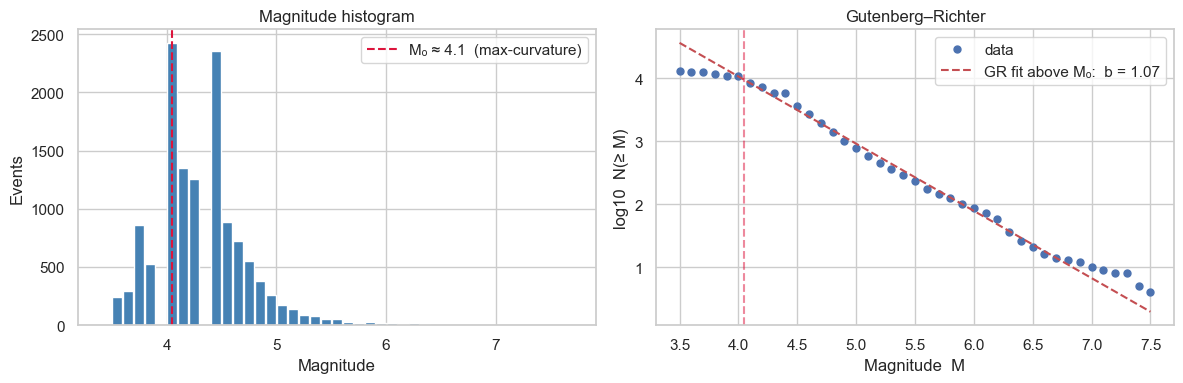

Mₒ ≈ 4.1    above which b ≈ 1.07  (29 bins fit)


In [4]:
bin_width = 0.1
bins = np.arange(3.4, df["mag"].max() + bin_width, bin_width)
hist, edges = np.histogram(df["mag"], bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
mc = centers[int(np.argmax(hist))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(centers, hist, width=bin_width * 0.9, color="steelblue", edgecolor="white")
axes[0].axvline(mc, color="crimson", ls="--", label=f"Mₒ ≈ {mc:.1f}  (max-curvature)")
axes[0].set(xlabel="Magnitude", ylabel="Events", title="Magnitude histogram")
axes[0].legend()

# Cumulative: log10 N(≥M) — should be linear above Mₒ.
m_grid = np.arange(3.5, 7.6, 0.1)
N_ge = np.array([(df["mag"] >= m).sum() for m in m_grid], dtype=float)
mask = (m_grid >= mc) & (N_ge > 10)
slope, intercept = np.polyfit(m_grid[mask], np.log10(N_ge[mask]), 1)
axes[1].plot(m_grid, np.log10(np.maximum(N_ge, 1)), "o", ms=5, label="data")
axes[1].plot(m_grid, slope * m_grid + intercept, "r--",
             label=f"GR fit above Mₒ:  b = {-slope:.2f}")
axes[1].axvline(mc, color="crimson", ls="--", alpha=0.5)
axes[1].set(xlabel="Magnitude  M", ylabel="log10  N(≥ M)", title="Gutenberg–Richter")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "01_magnitude.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Mₒ ≈ {mc:.1f}    above which b ≈ {-slope:.2f}  ({int(mask.sum())} bins fit)")

## 3. Depth distribution

Seismologists classify events by depth:

- **Shallow**: 0–70 km — most tectonic plate-boundary events.
- **Intermediate**: 70–300 km — subducting-slab events (e.g., Hindu Kush).
- **Deep**: > 300 km — rare; only in old, cold subducted lithosphere.

The South Asia bounding box covers both the shallow Himalayan-front thrust and
the famous **Hindu Kush intermediate-depth nest** (≈ 200 km). We expect a
bimodal depth distribution.

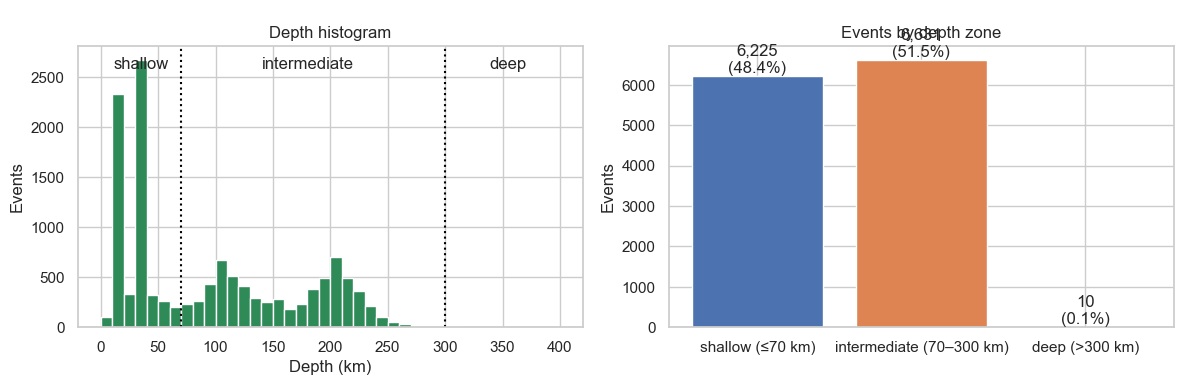

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["depth"], bins=np.arange(0, 410, 10), color="seagreen", edgecolor="white")
axes[0].axvline(70,  color="black", ls=":")
axes[0].axvline(300, color="black", ls=":")
axes[0].set(xlabel="Depth (km)", ylabel="Events", title="Depth histogram")
axes[0].text(35,  axes[0].get_ylim()[1] * 0.92, "shallow",       ha="center")
axes[0].text(180, axes[0].get_ylim()[1] * 0.92, "intermediate",  ha="center")
axes[0].text(355, axes[0].get_ylim()[1] * 0.92, "deep",          ha="center")

zones = pd.cut(df["depth"], bins=[-1, 70, 300, 800],
               labels=["shallow (≤70 km)", "intermediate (70–300 km)", "deep (>300 km)"])
zone_counts = zones.value_counts().sort_index()
axes[1].bar(zone_counts.index.astype(str), zone_counts.values, color=["#4c72b0", "#dd8452", "#55a868"])
axes[1].set(ylabel="Events", title="Events by depth zone")
for i, v in enumerate(zone_counts.values):
    axes[1].text(i, v, f"\n{v:,}\n({100*v/len(df):.1f}%)", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_depth.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Geography — where the events sit

A map of every event in the catalog. Colour = depth, marker size = magnitude.
The Hindu Kush deep nest, the Makran subduction zone, the Sulaiman/Kirthar
fold-and-thrust belt, and the Himalayan front should all light up.

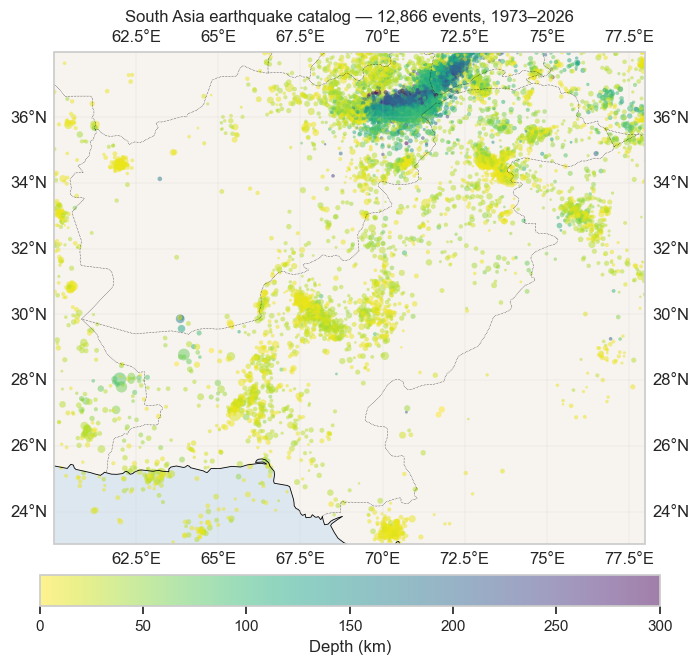

In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([60, 78, 23, 38], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("50m"),   facecolor="#f7f3ee")
ax.add_feature(cfeature.OCEAN.with_scale("50m"),  facecolor="#dde7ef")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.4, linestyle=":")

scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["depth"], cmap="viridis_r", vmin=0, vmax=300,
    s=(df["mag"] - 3.0) ** 2 * 4 + 2,
    alpha=0.5, transform=ccrs.PlateCarree(), edgecolors="none",
)
plt.colorbar(scatter, ax=ax, orientation="horizontal", pad=0.05,
             label="Depth (km)", shrink=0.8)
ax.set_title(f"South Asia earthquake catalog — {len(df):,} events, "
             f"{df['time'].min().year}–{df['time'].max().year}")
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

plt.savefig(FIG_DIR / "01_map.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Time — events per year and per month

How does the detection rate change over time? Newer years should have more
events (better instrumentation), and large mainshocks should produce visible
spikes from their aftershock sequences.

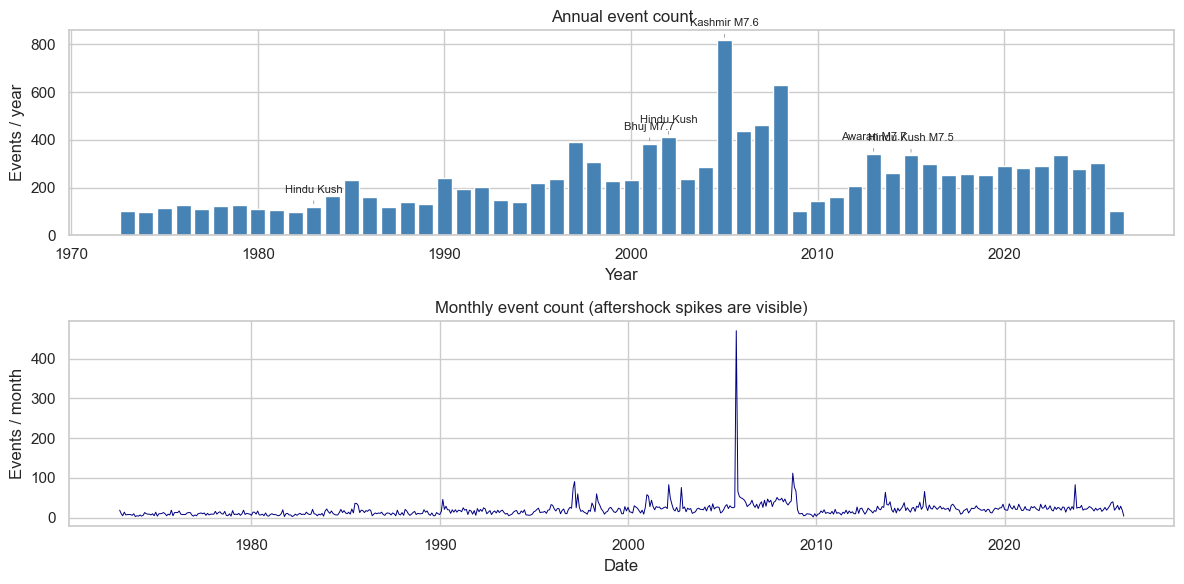

In [7]:
year = df["time"].dt.year
month = df["time"].dt.to_period("M")

events_per_year  = year.value_counts().sort_index()
events_per_month = month.value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].bar(events_per_year.index, events_per_year.values, color="steelblue", edgecolor="white")
axes[0].set(xlabel="Year", ylabel="Events / year", title="Annual event count")

# Annotate famous mainshock years
famous = {
    1983: "Hindu Kush",
    2001: "Bhuj M7.7",
    2002: "Hindu Kush",
    2005: "Kashmir M7.6",
    2013: "Awaran M7.7",
    2015: "Hindu Kush M7.5",
}
for yr, label in famous.items():
    if yr in events_per_year.index:
        axes[0].annotate(label, xy=(yr, events_per_year[yr]),
                         xytext=(0, 10), textcoords="offset points",
                         ha="center", fontsize=8,
                         arrowprops=dict(arrowstyle="-", color="grey", lw=0.5))

axes[1].plot(events_per_month.index.to_timestamp(), events_per_month.values,
             color="navy", linewidth=0.7)
axes[1].set(xlabel="Date", ylabel="Events / month",
            title="Monthly event count (aftershock spikes are visible)")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_time.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. The big ones — M ≥ 7 mainshocks

These are the events whose aftershock sequences will dominate the clustering
analysis later.

In [8]:
big = (
    df[df["mag"] >= 7.0]
    .sort_values("mag", ascending=False)
    [["time", "mag", "depth", "latitude", "longitude", "place"]]
    .reset_index(drop=True)
)
big["time"] = big["time"].dt.strftime("%Y-%m-%d")
print(f"{len(big)} events with M ≥ 7.0")
big

12 events with M ≥ 7.0


,time,mag,depth,latitude,longitude,place
0,2001-01-26,7.7,16.0,23.4190,70.2320,"17 km NW of Bhach?u, India"
1,2013-04-16,7.7,80.0,28.0330,61.9960,"79 km ESE of Kh?sh, Iran"
2,2013-09-24,7.7,15.0,26.9510,65.5009,"113 km NW of Bela, Pakistan"
3,2005-10-08,7.6,26.0,34.5390,73.5880,"21 km NNE of Muzaffar?b?d, Pakistan"
4,2015-10-26,7.5,231.0,36.5244,70.3676,"Hindu Kush region, Afghanistan"
5,1983-12-30,7.4,214.5,36.3720,70.7380,"55 km S of Jurm, Afghanistan"
6,1985-07-29,7.4,98.7,36.1900,70.8960,"75 km S of Jurm, Afghanistan"
7,2002-03-03,7.4,225.6,36.5020,70.4820,"51 km SW of Jurm, Afghanistan"
8,2011-01-18,7.2,68.0,28.7770,63.9510,"46 km WSW of Dalbandin, Pakistan"
9,1997-02-27,7.1,33.0,29.9760,68.2080,"29 km ESE of Harnai, Pakistan"


## 7. Data-quality audit

Two things to flag in the report:

1. **Missing values** in some property fields (`rms`, `gap`, `dmin`, `nst`)
   because not every reporting network supplies them.
2. **Encoding artefacts** in `place` (e.g. `Kh?sh`, `Bhach?u`, `Muzaffar?b?d`)
   — non-ASCII characters that USGS replaced with `?`. These are cosmetic; they
   do not affect any numeric feature.

In [9]:
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct    = (100 * na_counts / len(df)).round(1)
quality = pd.DataFrame({"missing": na_counts, "missing %": na_pct})
print(quality.to_string())

           missing  missing %
dmin          9131       71.0
nst           7096       55.2
gap           5547       43.1
rms            942        7.3
id               0        0.0
time             0        0.0
longitude        0        0.0
latitude         0        0.0
depth            0        0.0
mag              0        0.0
magType          0        0.0
place            0        0.0
type             0        0.0
status           0        0.0
net              0        0.0


In [10]:
bad_place = df["place"].fillna("").str.contains(r"\?", regex=True)
print(f"Place names with `?` artefacts: {bad_place.sum():,}  ({100*bad_place.mean():.1f}%)")
df.loc[bad_place, "place"].value_counts().head(10)

Place names with `?` artefacts: 5,084  (39.5%)


place
41 km SW of Ashk?sham, Afghanistan    22
43 km SW of Ashk?sham, Afghanistan    21
40 km SW of Ashk?sham, Afghanistan    21
46 km SW of Ashk?sham, Afghanistan    20
44 km SW of Ashk?sham, Afghanistan    20
49 km SW of Ashk?sham, Afghanistan    20
45 km SW of Ashk?sham, Afghanistan    19
42 km SW of Ashk?sham, Afghanistan    18
48 km SW of Ashk?sham, Afghanistan    17
36 km SW of Ashk?sham, Afghanistan    17
Name: count, dtype: int64

## 8. Takeaways

- **12,866 events** over **53 years** in the South Asia plate-boundary box,
  M ≥ 3.5.
- **Mₒ ≈ 4.0**, **b ≈ 1.0** — within textbook expectations for tectonic
  seismicity. The catalog is reliable for ML at and above this threshold.
- **Two depth populations**: shallow (Himalayan front, Makran, Kashmir) and
  intermediate (Hindu Kush nest at ~200 km).
- **Detection rate rises** through the catalog as instrumentation improves;
  large mainshock years are visible as clear spikes.
- **Data-quality caveats**: 4 property columns have missing values for events
  reported by older networks; some non-ASCII place names are mangled.

Next: [`02_features.ipynb`](02_features.ipynb) builds the per-event features
(Zaliapin η, local density, Båth and Omori residuals, etc.) on top of this
catalog.